# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [25]:
import pandas as pd
import numpy as np
from Bio import SeqIO
import matplotlib.pyplot as plt

In [26]:
import pandas as pd

df_aa = pd.read_csv(r"C:\Users\tveig\python-disciplina\Exercícios\15 - Medidas Resumo 1\q02_exer15.csv", index_col=0)

df_aa


,A,R,N,D,C,Q,E,G,H,I,L,K,M,F,P,S,T,W,Y,V
sigla,,,,,,,,,,,,,,,,,,,,
srs12b,31,16,18,24,13,11,22,27,2,11,28,22,3,8,20,48,43,3,3,33
sag1,37,5,10,12,14,8,13,24,4,14,21,21,6,10,21,30,35,3,3,28
tuba1,36,21,18,27,13,12,36,38,13,25,35,19,14,20,19,27,25,4,17,34
gra1,18,7,8,14,1,11,21,19,0,9,16,7,7,4,2,16,8,0,3,19
sag3,24,18,14,15,14,11,24,46,9,11,31,21,4,16,29,29,20,7,15,27


In [27]:
def tendencia_central(dados):
    media = dados.mean()
    mediana = dados.median()
    moda = dados.mode()[0]
    return {"media": media, "mediana": mediana, "moda": moda}
serinas = df_aa["S"]
resultado = tendencia_central(serinas)
print("Medidas de tendencia central da Serina (todos os genes):")
print(resultado)
print()
terceiro_gene = df_aa.iloc[2]
resultado_terceiro = tendencia_central(terceiro_gene)
print("Medidas de tendencia central do terceiro gene:")
print(resultado_terceiro)


Medidas de tendencia central da Serina (todos os genes):
{'media': np.float64(30.0), 'mediana': np.float64(29.0), 'moda': np.int64(16)}

Medidas de tendencia central do terceiro gene:
{'media': np.float64(22.65), 'mediana': np.float64(20.5), 'moda': np.int64(13)}


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [28]:
def amplitude(dados):
    return dados.max() - dados.min()
isoleucinas = df_aa["I"]
amp_ile = amplitude(isoleucinas)
print(f"Amplitude da Isoleucina: {amp_ile}")
print()
ultimo_gene = df_aa.iloc[-1]
amp_ultimo = amplitude(ultimo_gene)
print(f"Amplitude do ultimo gene ({ultimo_gene.name}): {amp_ultimo}")


Amplitude da Isoleucina: 16

Amplitude do ultimo gene (sag3): 42


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [29]:
def quartis(dados):
    q1 = dados.quantile(0.25)
    q2 = dados.quantile(0.50)
    q3 = dados.quantile(0.75)
    return {"Q1": q1, "Q2": q2, "Q3": q3}
metioninas = df_aa["M"]
q_metionina = quartis(metioninas)
print(f"Q1 da Metionina: {q_metionina['Q1']}")
print(f"Q2 (mediana) da Metionina: {q_metionina['Q2']}")
print(f"Q3 da Metionina: {q_metionina['Q3']}")
print()
primeiro_gene = df_aa.iloc[0]
q_primeiro = quartis(primeiro_gene)
print(f"Quartis do primeiro gene ({primeiro_gene.name}): Q1={q_primeiro['Q1']}, Q2={q_primeiro['Q2']}, Q3={q_primeiro['Q3']}")


Q1 da Metionina: 4.0
Q2 (mediana) da Metionina: 6.0
Q3 da Metionina: 7.0

Quartis do primeiro gene (srs12b): Q1=10.25, Q2=19.0, Q3=27.25


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

Intervalo interquartil do Acido Glutamico: 3.0

Intervalo interquartil do penultimo gene (gra1): 12.25



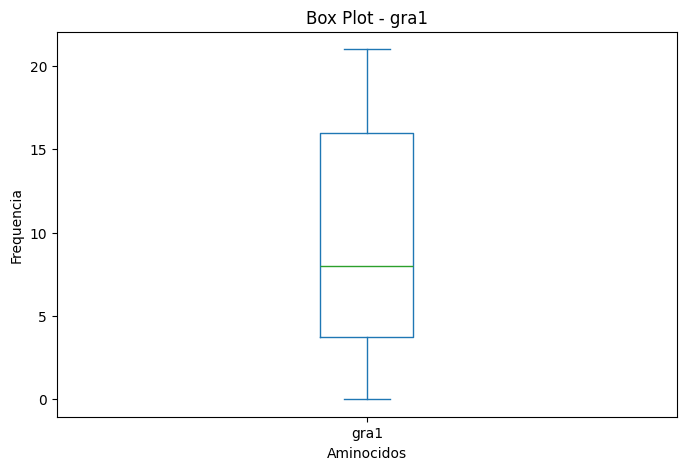

In [30]:
def intervalo_interquartil(dados):
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    return q3 - q1
acido_glutamico = df_aa["E"]
iir_eg = intervalo_interquartil(acido_glutamico)
print(f"Intervalo interquartil do Acido Glutamico: {iir_eg}")
print()
penultimo_gene = df_aa.iloc[-2]
iir_penultimo = intervalo_interquartil(penultimo_gene)
print(f"Intervalo interquartil do penultimo gene ({penultimo_gene.name}): {iir_penultimo}")
print()
plt.figure(figsize=(8, 5))
penultimo_gene.plot(kind="box")
plt.title(f"Box Plot - {penultimo_gene.name}")
plt.xlabel("Aminocidos")
plt.ylabel("Frequencia")
plt.show()


## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [31]:
def variancia_amostral(dados):
    return dados.var(ddof=1)
prolina = df_aa["P"]
var_p = variancia_amostral(prolina)
print(f"Variancia da Prolina: {var_p}")
print()
terceiro_gene = df_aa.iloc[2]
var_terceiro = variancia_amostral(terceiro_gene)
print(f"Variancia do terceiro gene ({terceiro_gene.name}): {var_terceiro}")


Variancia da Prolina: 97.70000000000002

Variancia do terceiro gene (tuba1): 91.2921052631579


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor do desvio padrão do Triptofano? E do gene de index -1?

In [32]:
def desvio_padrao(dados):
    return dados.std(ddof=1)
triptofano = df_aa["W"]
dp_w = desvio_padrao(triptofano)
print(f"Desvio padrao do Triptofano: {dp_w}")
print()
gene_index_menos1 = df_aa.iloc[-1]
dp_menos1 = desvio_padrao(gene_index_menos1)
print(f"Desvio padrao do gene de index -1 ({gene_index_menos1.name}): {dp_menos1}")


Desvio padrao do Triptofano: 2.5099800796022267

Desvio padrao do gene de index -1 (sag3): 9.946567776188719


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [33]:
def coef_variacao(dados):
    media = dados.mean()
    dp = dados.std(ddof=1)
    return (dp / media) * 100 if media != 0 else 0
leucina = df_aa["L"]
cv_l = coef_variacao(leucina)
print(f"Coeficiente de variacao da Leucina: {cv_l}")
print()
gene_index_1 = df_aa.iloc[1]
cv_index1 = coef_variacao(gene_index_1)
print(f"Coeficiente de variacao do gene de index 1 ({gene_index_1.name}): {cv_index1}")


Coeficiente de variacao da Leucina: 29.24271955630222

Coeficiente de variacao do gene de index 1 (sag1): 66.73896758647217


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [34]:
def medidas_resumo(dados):
    return {
        "media": dados.mean(),
        "mediana": dados.median(),
        "moda": dados.mode()[0],
        "amplitude": dados.max() - dados.min(),
        "Q1": dados.quantile(0.25),
        "Q2": dados.quantile(0.50),
        "Q3": dados.quantile(0.75),
        "IIR": dados.quantile(0.75) - dados.quantile(0.25),
        "variancia": dados.var(ddof=1),
        "desvio padrao": dados.std(ddof=1),
        "CV%": (dados.std(ddof=1) / dados.mean()) * 100 if dados.mean() != 0 else 0
    }
serinas = df_aa["S"]
resumo = medidas_resumo(serinas)
print("Medidas resumo da Serina:")
print(resumo)


Medidas resumo da Serina:
{'media': np.float64(30.0), 'mediana': np.float64(29.0), 'moda': np.int64(16), 'amplitude': np.int64(32), 'Q1': np.float64(27.0), 'Q2': np.float64(29.0), 'Q3': np.float64(30.0), 'IIR': np.float64(3.0), 'variancia': np.float64(132.5), 'desvio padrao': np.float64(11.510864433221338), 'CV%': np.float64(38.369548110737796)}


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

Gene com maior CV: gra1

Coeficiente de variacao por gene:
  srs12b: 68.25%
  sag1: 66.74%
  tuba1: 42.18%
  gra1: 72.33%
  sag3: 51.67%



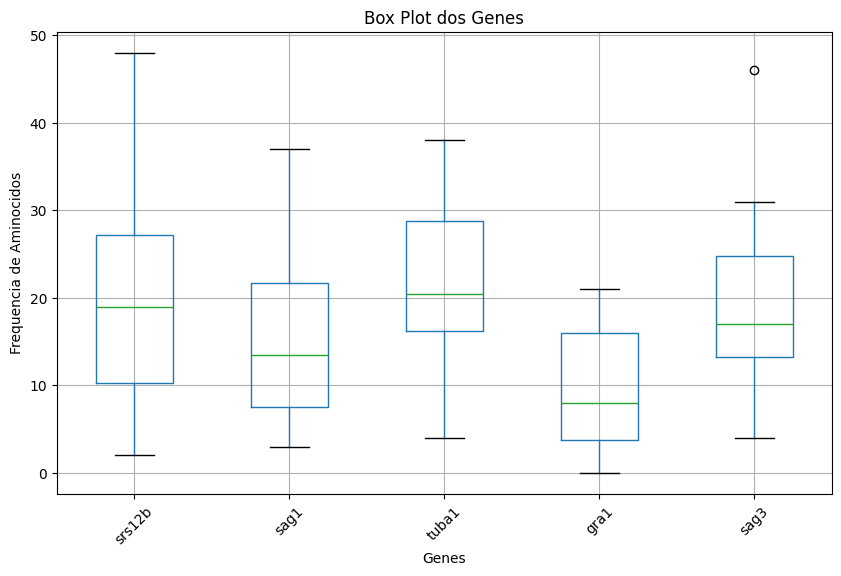

In [35]:
def maior_cv_genes(df):
    cvs = {}
    for gene in df.index:
        dados = df.loc[gene]
        media = dados.mean()
        dp = dados.std(ddof=1)
        cvs[gene] = (dp / media) * 100 if media != 0 else 0
    return max(cvs, key=cvs.get), cvs
gene_maior_cv, todos_cvs = maior_cv_genes(df_aa)
print(f"Gene com maior CV: {gene_maior_cv}")
print()
print("Coeficiente de variacao por gene:")
for g, cv in todos_cvs.items():
    print(f"  {g}: {cv:.2f}%")
print()
plt.figure(figsize=(10, 6))
df_aa.T.boxplot()
plt.title("Box Plot dos Genes")
plt.xlabel("Genes")
plt.ylabel("Frequencia de Aminocidos")
plt.xticks(rotation=45)
plt.show()


## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV amongst os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

Aminocido com maior CV: H

Coeficiente de variacao por aminocido:
  A: 27.76%
  R: 52.40%
  N: 33.53%
  D: 36.17%
  C: 51.02%
  Q: 14.31%
  E: 35.73%
  G: 35.67%
  H: 95.00%
  I: 45.74%
  L: 29.24%
  K: 34.69%
  M: 63.59%
  F: 55.06%
  P: 54.31%
  S: 38.37%
  T: 51.59%
  W: 73.82%
  Y: 87.26%
  V: 21.19%



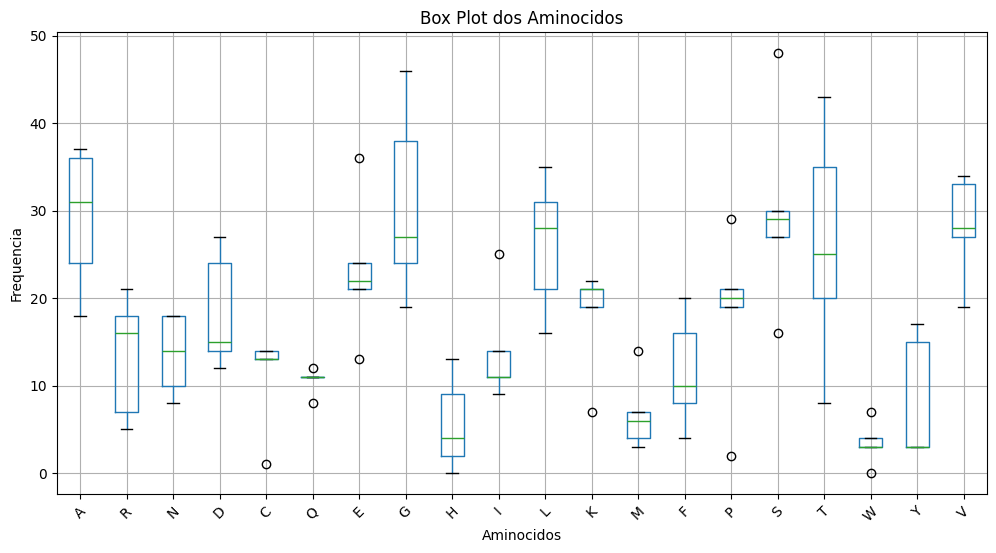

In [36]:
def maior_cv_aa(df):
    cvs = {}
    for aa in df.columns:
        dados = df[aa]
        media = dados.mean()
        dp = dados.std(ddof=1)
        cvs[aa] = (dp / media) * 100 if media != 0 else 0
    return max(cvs, key=cvs.get), cvs
aa_maior_cv, todos_cvs_aa = maior_cv_aa(df_aa)
print(f"Aminocido com maior CV: {aa_maior_cv}")
print()
print("Coeficiente de variacao por aminocido:")
for aa, cv in todos_cvs_aa.items():
    print(f"  {aa}: {cv:.2f}%")
print()
plt.figure(figsize=(12, 6))
df_aa.boxplot()
plt.title("Box Plot dos Aminocidos")
plt.xlabel("Aminocidos")
plt.ylabel("Frequencia")
plt.xticks(rotation=45)
plt.show()
